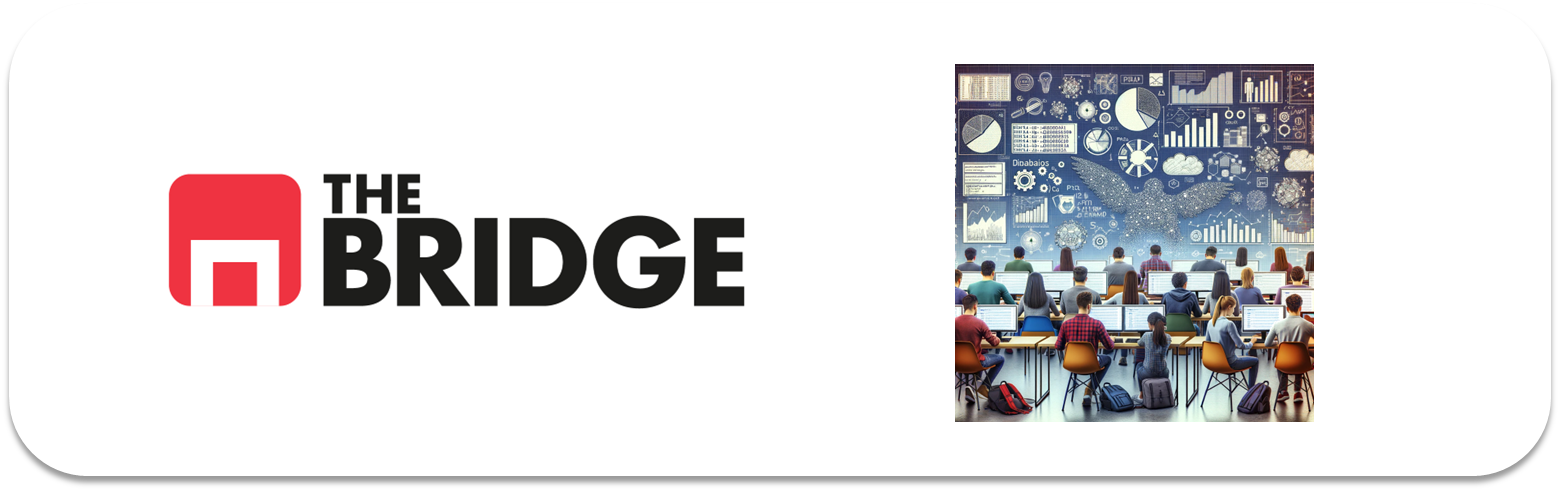

## PRACTICA OBLIGATORIA: **Clasificacion y Regresion Logistica**

* La práctica obligatoria de esta unidad consiste en modelar la supervivencia en el Titanic, por fin, además de una parte adicional multiclase. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    ConfusionMatrixDisplay
)

### Indicaciones

A continuación tienes las indicaciones para hacer el modelado. No necesariamente tienes que seguirlos al pie de la letra, porque a partir de ahora ya las práctica obligatorias dejarán de ser mayormente guiadas por ejercicios y serán más de libre desarrollo, aunque con objetivos específicos, claros y determinados. 

En concreto se pide hacer un modelo de regresión logística, evaluarlo contra un dataset de test reservado del original mostrando las métricas propias de los problemas de clasificación, la matriz de confusión y la curva ROC. Además se pide comparar las predicciones con los valores reales y al final adaptar el modelo a un problema multiclase.

Los pasos para guiar el trabajo:
1. Carga el dataset del Titanic. 
2. Deshazte de las variables que no vayas a usar. Limpia lo que creas necesarios pero no hagas imputaciones.
3. Escoge y analiza la variable target de forma gráfica y razona sobre el impacto de la distribución en los resultados esperados. Ten en cuenta que lo que queremos es poder predecir si un pasajero sobrevivirá.
4. Haz el split en train y test que creas conveniente pero asegurándote que ambos conjuntos tienen un reparto similar de pasajeros embarcados en las tres ciudades.
5. Construye las parejas X,y de train y test.
6. Ahora sí imputa los nulos con medias y modas en la X de train. Guarda esas medias que necesitarás en la parte de test.
7. Haz un mini-EDA, selecciona las features que quieres quedarte y por qué.
8. Trata las variables para que funcionen lo mejor posible en el modelo.
9. Construye un modelo de regresión logística.
10. EXTRA: Analiza si lo crees conveniente los pesos y la importancia de las features.
11. Procesa el dataset de Test para que puedas usarlo en la evaluación 
12. Evalúa tu modelo contra el dataset de test y train. Obten las matrices de confusión y las métricas que creas adecuadas. Haz un pequeño assesment de su generabilidad.
13. EXTRA: Halla la probabilidad de supervivencia de un hombre de entre 30 y 40 años, que embarcó en Southampton en segunda clase, viajaba solo y no pagó el billete. PISTA: En este caso tendrás que calcular varias probabilidades y hacer la media de ellas.
14. EXTRA: Aprovecha todo el trabajo haciendo un único cambio en el target, ahora será la clase del viajero. Cambia el target quitándolo de X_train, X_test y añade a estos el target anterior. El resto no deberías cambiarlo. Entrena y evalua el modelo sólo con el classification_report.  



In [3]:
df = pd.read_csv("data/titanic.csv")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
df.drop(columns=["alive", "class", "who", "adult_male", "embark_town", "deck"], inplace=True)
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,0,3,male,22.0,1,0,7.2500,S,False
1,1,1,female,38.0,1,0,71.2833,C,False
2,1,3,female,26.0,0,0,7.9250,S,True
3,1,1,female,35.0,1,0,53.1000,S,False
4,0,3,male,35.0,0,0,8.0500,S,True


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    object 
 3   age       714 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  889 non-null    object 
 8   alone     891 non-null    bool   
dtypes: bool(1), float64(2), int64(4), object(2)
memory usage: 56.7+ KB


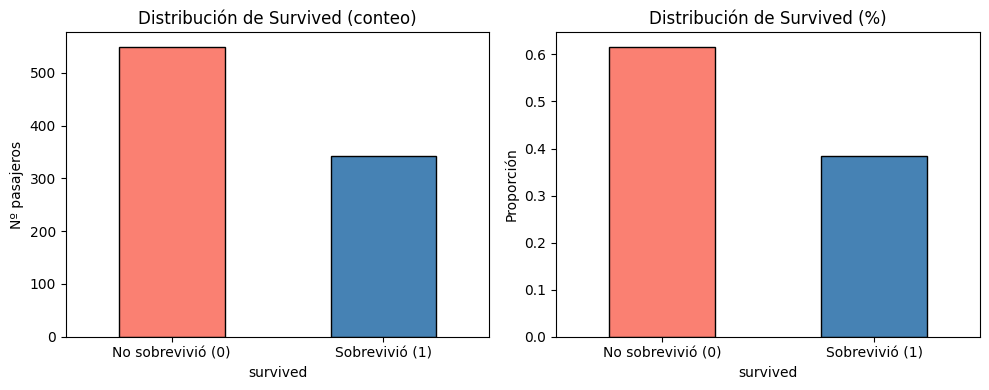

survived
0    549
1    342
Name: count, dtype: int64
survived
0    0.62
1    0.38
Name: proportion, dtype: float64


In [6]:
# Distribución del target
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Conteo absoluto
df["survived"].value_counts().plot(kind="bar", ax=axes[0], color=["salmon", "steelblue"], edgecolor="black")
axes[0].set_title("Distribución de Survived (conteo)")
axes[0].set_xticklabels(["No sobrevivió (0)", "Sobrevivió (1)"], rotation=0)
axes[0].set_ylabel("Nº pasajeros")

# Porcentaje
df["survived"].value_counts(normalize=True).plot(kind="bar", ax=axes[1], color=["salmon", "steelblue"], edgecolor="black")
axes[1].set_title("Distribución de Survived (%)")
axes[1].set_xticklabels(["No sobrevivió (0)", "Sobrevivió (1)"], rotation=0)
axes[1].set_ylabel("Proporción")

plt.tight_layout()
plt.show()

print(df["survived"].value_counts())
print(df["survived"].value_counts(normalize=True).round(2))

In [7]:
from sklearn.model_selection import train_test_split

df.dropna(subset=["embarked"], inplace=True)

train, test = train_test_split(df, test_size=0.2, random_state=42, stratify=df["embarked"])

print("Train:", train.shape)
print("Test:", test.shape)

# Verificamos que el reparto de embarked es similar en ambos
print("\nEmbarked en train:")
print(train["embarked"].value_counts(normalize=True).round(2))
print("\nEmbarked en test:")
print(test["embarked"].value_counts(normalize=True).round(2))

Train: (711, 9)
Test: (178, 9)

Embarked en train:
embarked
S    0.72
C    0.19
Q    0.09
Name: proportion, dtype: float64

Embarked en test:
embarked
S    0.72
C    0.19
Q    0.08
Name: proportion, dtype: float64


In [8]:
# Construir las parejas X e y de train y test
X_train = train.drop(columns=["survived"])
y_train = train["survived"]

X_test = test.drop(columns=["survived"])
y_test = test["survived"]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (711, 8)
X_test: (178, 8)
y_train: (711,)
y_test: (178,)


In [9]:
# Calculamos media y moda SOLO sobre X_train
age_mean = X_train["age"].mean()
embarked_mode = X_train["embarked"].mode()[0]

print("Media de age:", age_mean)
print("Moda de embarked:", embarked_mode)

# Imputamos X_train
X_train["age"] = X_train["age"].fillna(age_mean)
X_train["embarked"] = X_train["embarked"].fillna(embarked_mode)

# Verificamos que no quedan nulos
print("\nNulos en X_train:")
print(X_train.isnull().sum())

Media de age: 29.7104537521815
Moda de embarked: S

Nulos en X_train:
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
alone       0
dtype: int64


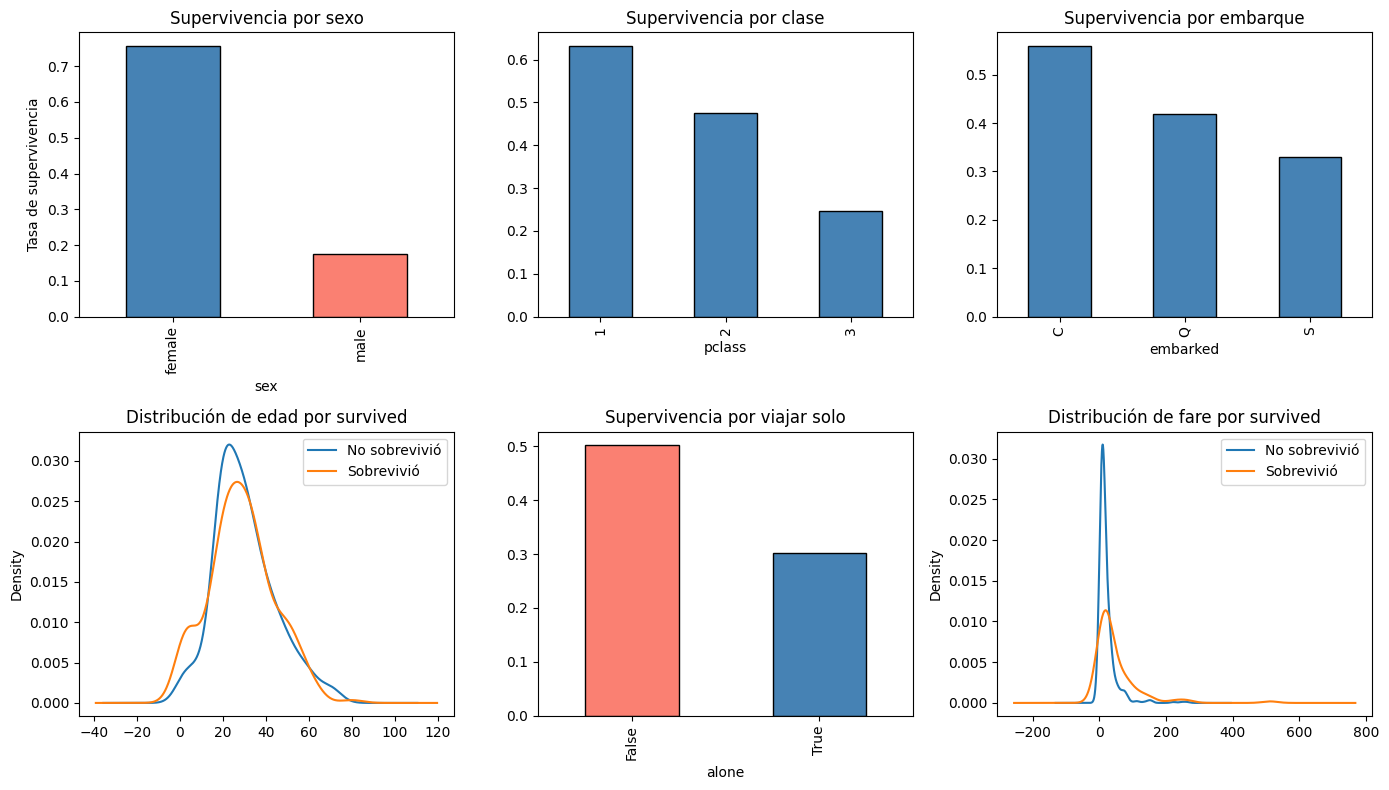

In [10]:
# Mini-EDA
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# Survived por sexo
train.groupby("sex")["survived"].mean().plot(kind="bar", ax=axes[0,0], color=["steelblue", "salmon"], edgecolor="black")
axes[0,0].set_title("Supervivencia por sexo")
axes[0,0].set_ylabel("Tasa de supervivencia")

# Survived por pclass
train.groupby("pclass")["survived"].mean().plot(kind="bar", ax=axes[0,1], color="steelblue", edgecolor="black")
axes[0,1].set_title("Supervivencia por clase")

# Survived por embarked
train.groupby("embarked")["survived"].mean().plot(kind="bar", ax=axes[0,2], color="steelblue", edgecolor="black")
axes[0,2].set_title("Supervivencia por embarque")

# Distribución de age por survived
train.groupby("survived")["age"].plot(kind="kde", ax=axes[1,0], legend=True)
axes[1,0].set_title("Distribución de edad por survived")
axes[1,0].legend(["No sobrevivió", "Sobrevivió"])

# Survived por alone
train.groupby("alone")["survived"].mean().plot(kind="bar", ax=axes[1,1], color=["salmon", "steelblue"], edgecolor="black")
axes[1,1].set_title("Supervivencia por viajar solo")

# Distribución de fare por survived
train.groupby("survived")["fare"].plot(kind="kde", ax=axes[1,2], legend=True)
axes[1,2].set_title("Distribución de fare por survived")
axes[1,2].legend(["No sobrevivió", "Sobrevivió"])

plt.tight_layout()
plt.show()

In [11]:
X_train = X_train.drop(columns=["sibsp", "parch"])
X_test = X_test.drop(columns=["sibsp", "parch"])

print(X_train.columns.tolist())

['pclass', 'sex', 'age', 'fare', 'embarked', 'alone']


In [12]:
# 1. Encoding de variables categóricas y booleanas
X_train["sex"] = X_train["sex"].map({"male": 0, "female": 1})
X_train["alone"] = X_train["alone"].astype(int)
X_train = pd.get_dummies(X_train, columns=["embarked"], drop_first=True)

X_test["sex"] = X_test["sex"].map({"male": 0, "female": 1})
X_test["alone"] = X_test["alone"].astype(int)
X_test = pd.get_dummies(X_test, columns=["embarked"], drop_first=True)

print(X_train.head())
print(X_train.dtypes)

     pclass  sex        age    fare  alone  embarked_Q  embarked_S
46        3    0  29.710454  15.500      0        True       False
230       1    1  35.000000  83.475      0       False        True
657       3    1  32.000000  15.500      0        True       False
888       3    1  29.710454  23.450      0       False        True
809       1    1  33.000000  53.100      0       False        True
pclass          int64
sex             int64
age           float64
fare          float64
alone           int64
embarked_Q       bool
embarked_S       bool
dtype: object


In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Columnas numéricas que necesitan escalado
cols_to_scale = ["age", "fare", "pclass"]

X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

print(X_train.head())

       pclass  sex       age      fare  alone  embarked_Q  embarked_S
46   0.798150    0  0.000000 -0.315512      0        True       False
230 -1.621828    1  0.405812  1.012731      0       False        True
657  0.798150    1  0.175653 -0.315512      0        True       False
888  0.798150    1  0.000000 -0.160167      0       False        True
809 -1.621828    1  0.252373  0.419199      0       False        True


In [14]:
X_train["embarked_Q"] = X_train["embarked_Q"].astype(int)
X_train["embarked_S"] = X_train["embarked_S"].astype(int)
X_test["embarked_Q"] = X_test["embarked_Q"].astype(int)
X_test["embarked_S"] = X_test["embarked_S"].astype(int)

print(X_train.dtypes)

pclass        float64
sex             int64
age           float64
fare          float64
alone           int64
embarked_Q      int64
embarked_S      int64
dtype: object


In [15]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)

print("Modelo entrenado ✓")

Modelo entrenado ✓


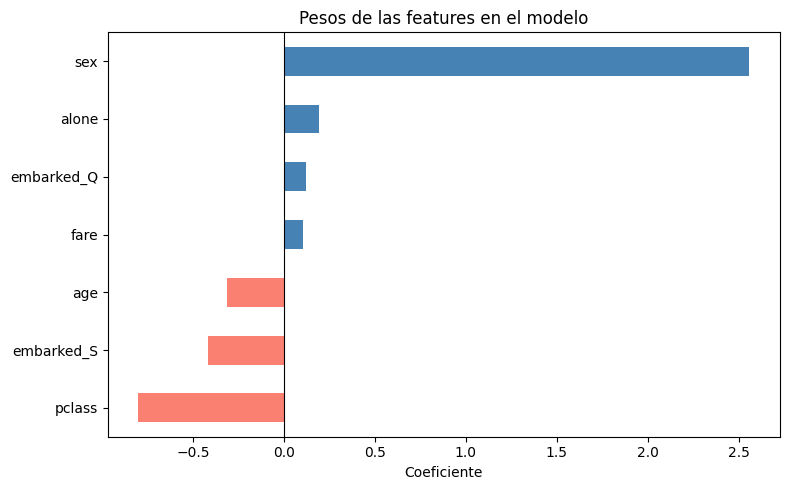

pclass       -0.799923
embarked_S   -0.415816
age          -0.310543
fare          0.106197
embarked_Q    0.119665
alone         0.191501
sex           2.558562
dtype: float64


In [17]:
# Análisis de los pesos de las features
pesos = pd.Series(model.coef_[0], index=X_train.columns).sort_values()

plt.figure(figsize=(8, 5))
pesos.plot(kind="barh", color=["salmon" if x < 0 else "steelblue" for x in pesos])
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Pesos de las features en el modelo")
plt.xlabel("Coeficiente")
plt.tight_layout()
plt.show()

print(pesos)

In [18]:
print("Nulos en X_test:")
print(X_test.isnull().sum())

# Imputamos con la media que calculamos sobre X_train (no la de X_test)
X_test["age"] = X_test["age"].fillna(age_mean)

print("\nNulos en X_test tras imputar:")
print(X_test.isnull().sum())

Nulos en X_test:
pclass         0
sex            0
age           39
fare           0
alone          0
embarked_Q     0
embarked_S     0
dtype: int64

Nulos en X_test tras imputar:
pclass        0
sex           0
age           0
fare          0
alone         0
embarked_Q    0
embarked_S    0
dtype: int64


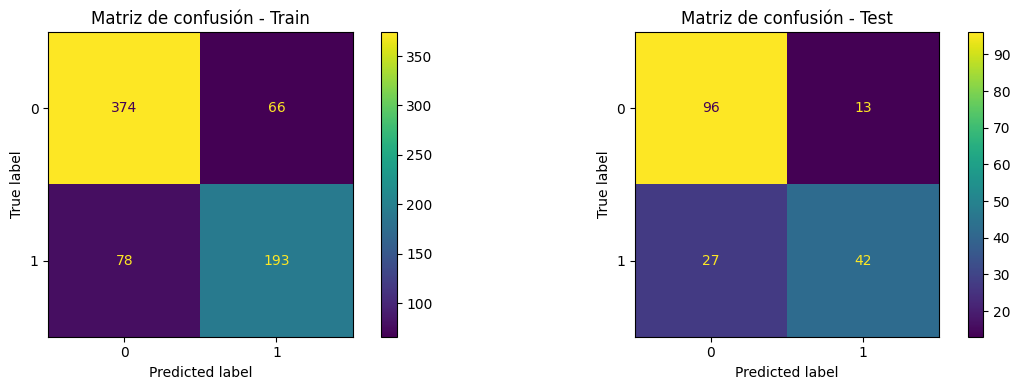

=== TRAIN ===
              precision    recall  f1-score   support

           0       0.83      0.85      0.84       440
           1       0.75      0.71      0.73       271

    accuracy                           0.80       711
   macro avg       0.79      0.78      0.78       711
weighted avg       0.80      0.80      0.80       711

=== TEST ===
              precision    recall  f1-score   support

           0       0.78      0.88      0.83       109
           1       0.76      0.61      0.68        69

    accuracy                           0.78       178
   macro avg       0.77      0.74      0.75       178
weighted avg       0.77      0.78      0.77       178



In [20]:
# Evaluación del modelo

from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Predicciones
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

# Matrices de confusión
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay(confusion_matrix(y_train, y_pred_train)).plot(ax=axes[0])
axes[0].set_title("Matriz de confusión - Train")

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_test)).plot(ax=axes[1])
axes[1].set_title("Matriz de confusión - Test")

plt.tight_layout()
plt.show()

# Métricas
print("=== TRAIN ===")
print(classification_report(y_train, y_pred_train))

print("=== TEST ===")
print(classification_report(y_test, y_pred_test))

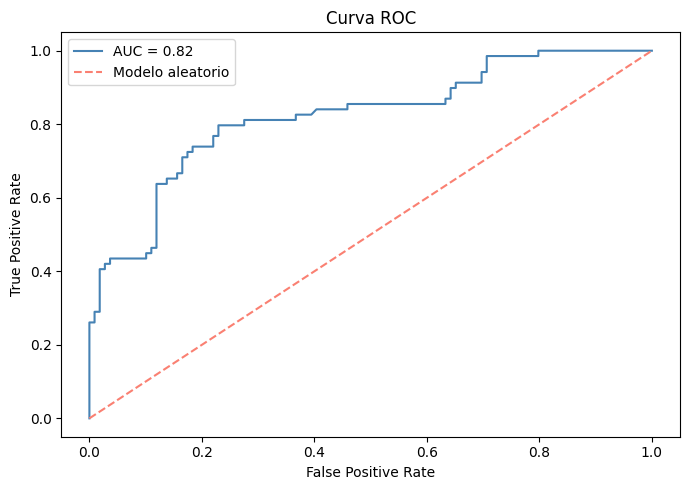

In [21]:
# Curva ROC
from sklearn.metrics import roc_curve, roc_auc_score

y_prob_test = model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob_test)
auc = roc_auc_score(y_test, y_prob_test)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color="steelblue", label=f"AUC = {auc:.2f}")
plt.plot([0, 1], [0, 1], color="salmon", linestyle="--", label="Modelo aleatorio")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
# Creamos un perfil por cada edad entre 30 y 40
perfiles = []

for edad in range(30, 41):
    perfiles.append({
        "pclass": 2,
        "sex": 0,          # male
        "age": edad,
        "fare": 0,
        "alone": 1,        # viaja solo
        "embarked_Q": 0,
        "embarked_S": 1    # Southampton
    })

perfil_df = pd.DataFrame(perfiles)

# Aplicamos el mismo escalado que usamos en train
perfil_df[cols_to_scale] = scaler.transform(perfil_df[cols_to_scale])

# Calculamos probabilidades
probabilidades = model.predict_proba(perfil_df)[:, 1]

for edad, prob in zip(range(30, 41), probabilidades):
    print(f"Edad {edad}: {prob:.2%}")

print(f"\nProbabilidad media: {probabilidades.mean():.2%}")

Edad 30: 20.79%
Edad 31: 20.40%
Edad 32: 20.02%
Edad 33: 19.64%
Edad 34: 19.26%
Edad 35: 18.90%
Edad 36: 18.53%
Edad 37: 18.18%
Edad 38: 17.83%
Edad 39: 17.48%
Edad 40: 17.14%

Probabilidad media: 18.92%


In [24]:
# Nuevo target (pclass en vez de survived)
y_train_multi = train["pclass"]
y_test_multi = test["pclass"]

# Nuevas X: quitamos pclass (ya está escalada) y añadimos survived
X_train_multi = X_train.drop(columns=["pclass"])
X_train_multi["survived"] = y_train.values

X_test_multi = X_test.drop(columns=["pclass"])
X_test_multi["survived"] = y_test.values

print(X_train_multi.head())

     sex       age      fare  alone  embarked_Q  embarked_S  survived
46     0  0.000000 -0.315512      0           1           0         0
230    1  0.405812  1.012731      0           0           1         1
657    1  0.175653 -0.315512      0           1           0         0
888    1  0.000000 -0.160167      0           0           1         0
809    1  0.252373  0.419199      0           0           1         1


In [25]:
model_multi = LogisticRegression(random_state=42, max_iter=1000)
model_multi.fit(X_train_multi, y_train_multi)

y_pred_multi = model_multi.predict(X_test_multi)

print(classification_report(y_test_multi, y_pred_multi))

              precision    recall  f1-score   support

           1       0.59      0.94      0.73        51
           2       0.60      0.22      0.32        41
           3       0.63      0.60      0.62        86

    accuracy                           0.61       178
   macro avg       0.61      0.59      0.56       178
weighted avg       0.61      0.61      0.58       178



- Clase 1 (primera clase) → recall de 0.94, muy alto. El modelo detecta casi todos los pasajeros de primera clase. Pero precision de 0.59 — cuando predice "primera clase" se equivoca bastante.
- Clase 2 (segunda clase) → el peor resultado. Recall de 0.22 — se pierde el 78% de los pasajeros de segunda clase. Es la clase más difícil de identificar, probablemente porque sus características se solapan con las otras dos.
- Clase 3 (tercera clase) → el más equilibrado. Precision 0.63, recall 0.60.